# Task 1 — Inner Workings of ResNet-152

## Baseline Setup

In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
np.random.seed(0)

if torch.cuda.is_available():
    device=torch.device("cuda")
elif torch.backends.mps.is_available():
    device=torch.device("mps")
else:
    device=torch.device("cpu")
print(device)

cuda


In [2]:
weights=models.ResNet152_Weights.DEFAULT
print(weights.transforms())

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [3]:
transform=weights.transforms()
training_set=datasets.CIFAR10(root="../data",train=True,
                             download=True,transform=transform)
testing_set=datasets.CIFAR10(root="../data",train=False,
                            download=True,transform=transform)
training_loader=DataLoader(training_set,batch_size=32,shuffle=True)
testing_loader=DataLoader(testing_set,batch_size=32,shuffle=False)

100%|██████████| 170M/170M [18:47<00:00, 151kB/s]


In [4]:
model=models.resnet152(weights=models.ResNet152_Weights.DEFAULT)
for parameter in model.parameters():
    parameter.requires_grad=False

features_count=model.fc.in_features
model.fc=nn.Linear(features_count,10)
model=model.to(device)

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 177MB/s]


In [5]:
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.fc.parameters(),lr=0.001)

epochs=3
training_losses=[]
validation_losses=[]

for epoch in range(epochs):
    #training
    model.train()
    running_loss=0.0
    for images,labels in training_loader:
        images,labels=images.to(device),labels.to(device)
        optimizer.zero_grad()
        outputs=model(images)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss=running_loss+loss.item()
    training_losses.append(running_loss/len(training_loader))

    #validation
    model.eval()
    validation_loss = 0.0
    with torch.no_grad():
        for images,labels in testing_loader:
            images,labels=images.to(device),labels.to(device)
            outputs=model(images)
            loss=criterion(outputs, labels)
            validation_loss=validation_loss+loss.item()
    validation_losses.append(validation_loss/len(testing_loader))

    print("Epoch",epoch+1)
    print("training: ",training_losses[-1])
    print("validation: ",validation_losses[-1])

Epoch 1
training:  0.6887923088866171
validation:  0.5196053310990715
Epoch 2
training:  0.5146034601706385
validation:  0.4910646066688501
Epoch 3
training:  0.4802885951137055
validation:  0.4828342499253087


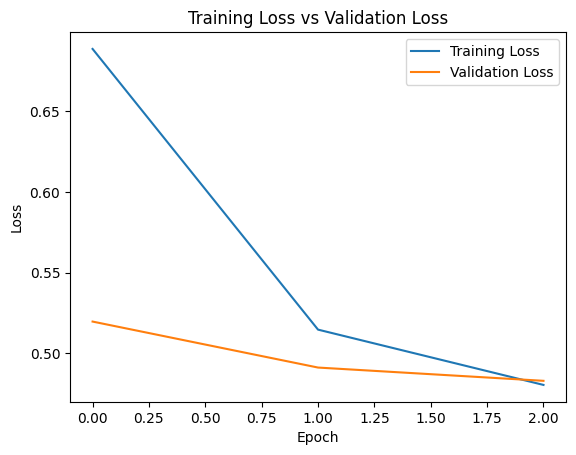

In [6]:
plt.plot(training_losses,label="Training Loss")
plt.plot(validation_losses,label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")
plt.legend()
plt.savefig("baseline_loss.png")
plt.show()

## Residual Connections in Practice

In [7]:
import types
noskipmodel=models.resnet152(weights=models.ResNet152_Weights.DEFAULT)
def forward_no_skip(self,x):
    out=self.conv1(x)
    out=self.bn1(out)
    out=self.relu(out)
    out=self.conv2(out)
    out=self.bn2(out)
    out=self.relu(out)
    out=self.conv3(out)
    out=self.bn3(out)
    out=self.relu(out)
    return out
noskipmodel.layer4[1].forward=types.MethodType(forward_no_skip,noskipmodel.layer4[1])
noskipmodel.layer4[2].forward=types.MethodType(forward_no_skip,noskipmodel.layer4[2])

for parameter in noskipmodel.parameters():
    parameter.requires_grad=False

features_count=noskipmodel.fc.in_features
noskipmodel.fc=nn.Linear(features_count,10)
noskipmodel=noskipmodel.to(device)

In [8]:
dummy=torch.randn(2,3,224,224).to(device)
print(noskipmodel(dummy).shape)

torch.Size([2, 10])


In [9]:
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(noskipmodel.fc.parameters(),lr=0.001)

epochs=3
noskip_training_losses=[]
noskip_validation_losses=[]

for epoch in range(epochs):
    #training
    noskipmodel.train()
    running_loss=0.0
    for images,labels in training_loader:
        images,labels=images.to(device),labels.to(device)
        optimizer.zero_grad()
        outputs=noskipmodel(images)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss=running_loss+loss.item()
    noskip_training_losses.append(running_loss/len(training_loader))

    #validation
    noskipmodel.eval()
    validation_loss=0.0
    with torch.no_grad():
        for images,labels in testing_loader:
            images,labels=images.to(device),labels.to(device)
            outputs=noskipmodel(images)
            loss=criterion(outputs,labels)
            validation_loss=validation_loss+loss.item()
    noskip_validation_losses.append(validation_loss/len(testing_loader))

    print("Epoch",epoch+1)
    print("training: ",noskip_training_losses[-1])
    print("validation: ",noskip_validation_losses[-1])

Epoch 1
training:  2.0236348952533185
validation:  1.855137072051295
Epoch 2
training:  1.8156992637111984
validation:  1.7473350751895111
Epoch 3
training:  1.735416117953095
validation:  1.6785973687522329


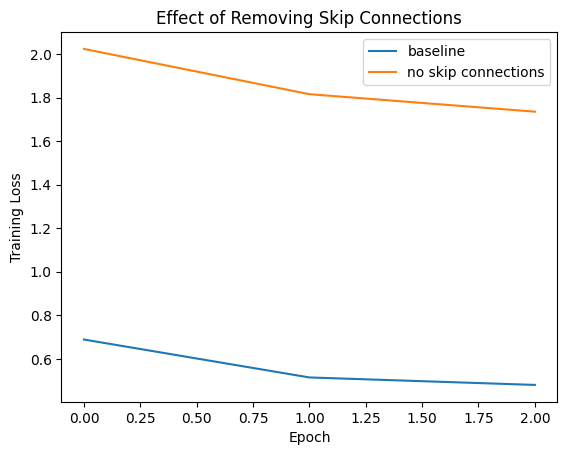

In [10]:
plt.plot(training_losses,label="baseline")
plt.plot(noskip_training_losses,label="no skip connections")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Effect of Removing Skip Connections")
plt.legend()
plt.savefig("residual_comparison.png")
plt.show()

## Feature Heirarchies and Representations

In [11]:
feature_extractor_model=models.resnet152(weights=models.ResNet152_Weights.DEFAULT)
feature_extractor_model=feature_extractor_model.to(device)
feature_extractor_model.eval()

early_layer_features=[]
middle_layer_features=[]
late_layer_features=[]

def early_layer_hook(module,input,output):
    early_layer_features.append(output.detach())

def middle_layer_hook(module,input,output):
    middle_layer_features.append(output.detach())

def late_layer_hook(module,input,output):
    late_layer_features.append(output.detach())

feature_extractor_model.layer1.register_forward_hook(early_layer_hook)
feature_extractor_model.layer2.register_forward_hook(middle_layer_hook)
feature_extractor_model.layer4.register_forward_hook(late_layer_hook)

In [12]:
images,labels=next(iter(testing_loader))
images=images.to(device)

with torch.no_grad():
    feature_extractor_model(images)

early_features=early_layer_features[0].mean(dim=[2,3]).cpu().numpy()
middle_features=middle_layer_features[0].mean(dim=[2,3]).cpu().numpy()
late_features=late_layer_features[0].mean(dim=[2,3]).cpu().numpy()
labels_array=labels.numpy()

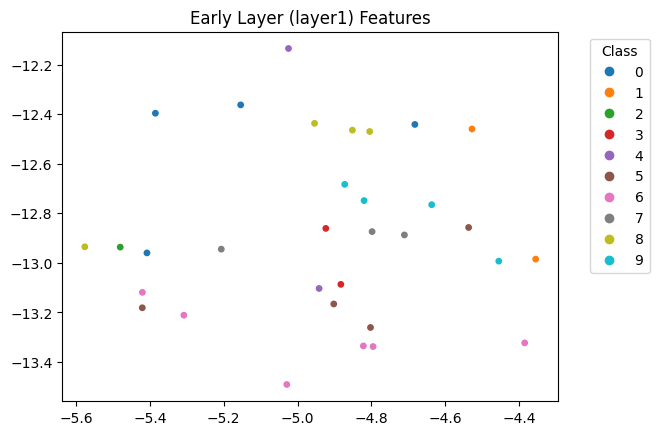

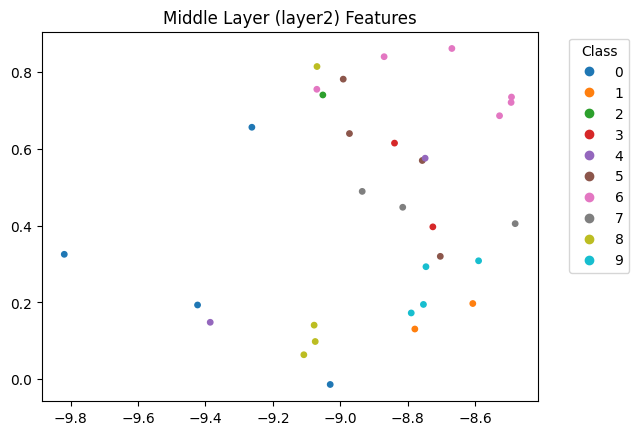

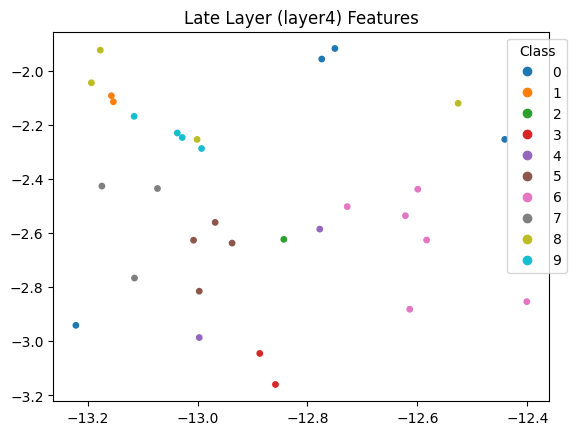

In [13]:
from sklearn.manifold import TSNE

def plot_layer_features(features,title,filename):
    reduced=TSNE(n_components=2,random_state=42).fit_transform(features)
    plt.figure()
    scatter=plt.scatter(reduced[:,0],reduced[:,1],c=labels_array,cmap="tab10",s=15)
    plt.title(title)
    plt.legend(*scatter.legend_elements(),title="Class",bbox_to_anchor=(1.05,1))
    plt.savefig(filename,bbox_inches="tight")
    plt.show()

plot_layer_features(early_features,"Early Layer (layer1) Features","tsne_early.png")
plot_layer_features(middle_features,"Middle Layer (layer2) Features","tsne_middle.png")
plot_layer_features(late_features,"Late Layer (layer4) Features","tsne_late.png")

### Note on batch size for feature visualization

The training experiments use a batch size of 32. For the t-SNE visualization, 32 points (~3 per class across 10 classes) are too few for cluster structure to emerge. So extracting features from a single larger batch of 500 test images so that t-SNE has enough samples per class (~50) to reveal how class separability evolves across layers.

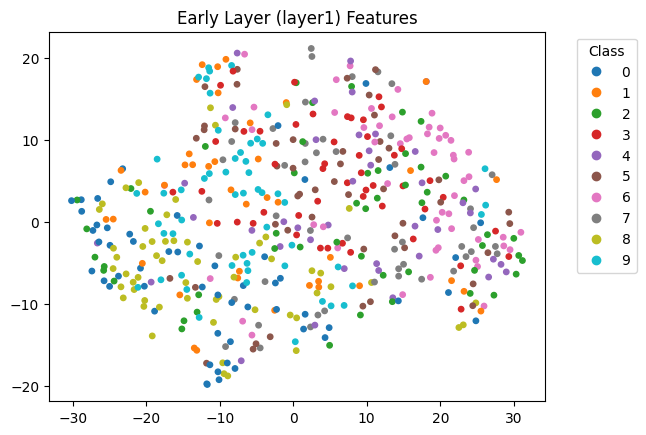

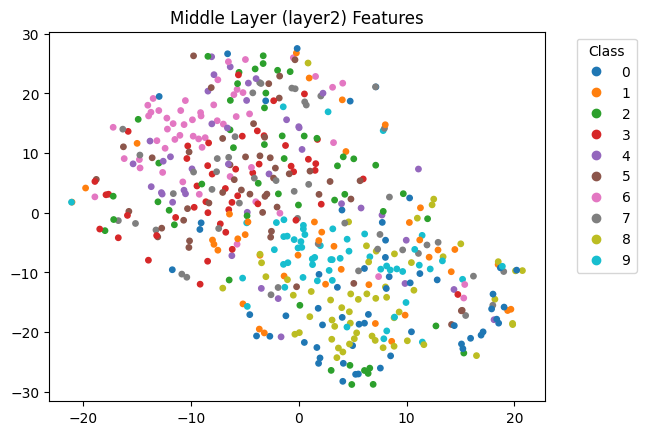

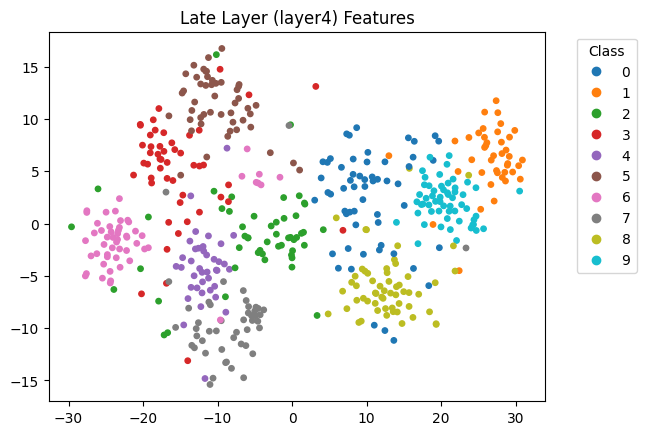

In [14]:
loader_500=DataLoader(testing_set,batch_size=500,shuffle=False)

early_layer_features.clear()
middle_layer_features.clear()
late_layer_features.clear()

images,labels=next(iter(loader_500))
images=images.to(device)

with torch.no_grad():
    feature_extractor_model(images)

early_features=early_layer_features[0].mean(dim=[2,3]).cpu().numpy()
middle_features=middle_layer_features[0].mean(dim=[2,3]).cpu().numpy()
late_features=late_layer_features[0].mean(dim=[2,3]).cpu().numpy()
labels_array=labels.numpy()
plot_layer_features(early_features,"Early Layer (layer1) Features","tsne_early.png")
plot_layer_features(middle_features,"Middle Layer (layer2) Features","tsne_middle.png")
plot_layer_features(late_features,"Late Layer (layer4) Features","tsne_late.png")

## Transfer Learning and Generalization

In [15]:
def train_and_evaluate(model,trainable_parameters,epochs=3):
    criterion=nn.CrossEntropyLoss()
    optimizer=torch.optim.Adam(trainable_parameters,lr=0.001)
    train_losses=[]
    val_losses=[]

    for epoch in range(epochs):
        model.train()
        running_loss=0.0
        for images,labels in training_loader:
            images,labels=images.to(device),labels.to(device)
            optimizer.zero_grad()
            outputs=model(images)
            loss=criterion(outputs,labels)
            loss.backward()
            optimizer.step()
            running_loss=running_loss+loss.item()
        train_losses.append(running_loss/len(training_loader))

        model.eval()
        val_loss=0.0
        with torch.no_grad():
            for images,labels in testing_loader:
                images,labels=images.to(device),labels.to(device)
                outputs=model(images)
                loss=criterion(outputs,labels)
                val_loss=val_loss+loss.item()
        val_losses.append(val_loss/len(testing_loader))

        print("Epoch",epoch+1)
        print("training: ",train_losses[-1])
        print("validation: ",val_losses[-1])

    return train_losses,val_losses

In [16]:
model_lastblock=models.resnet152(weights=models.ResNet152_Weights.DEFAULT)
for parameter in model_lastblock.parameters():
    parameter.requires_grad=False
for parameter in model_lastblock.layer4.parameters():
    parameter.requires_grad=True
model_lastblock.fc=nn.Linear(model_lastblock.fc.in_features,10)
model_lastblock=model_lastblock.to(device)
trainable_parameters=[]
for parameter in model_lastblock.parameters():
    if parameter.requires_grad:
        trainable_parameters.append(parameter)

lastblock_train,lastblock_val=train_and_evaluate(model_lastblock,trainable_parameters)

Epoch 1
training:  0.40567570042892365
validation:  0.28303373596681575
Epoch 2
training:  0.19876797691521475
validation:  0.2561947891173271
Epoch 3
training:  0.11620481883089868
validation:  0.27873187087857115


In [17]:
model_full=models.resnet152(weights=models.ResNet152_Weights.DEFAULT)
model_full.fc=nn.Linear(model_full.fc.in_features,10)
model_full=model_full.to(device)
full_train,full_val=train_and_evaluate(model_full,list(model_full.parameters()))

Epoch 1
training:  0.6071573263004432
validation:  0.4256926773788449
Epoch 2
training:  0.3392595459497936
validation:  0.44293381671269483
Epoch 3
training:  0.24917508833413027
validation:  0.33106770509252914


In [18]:
model_random=models.resnet152(weights=None)
model_random.fc=nn.Linear(model_random.fc.in_features,10)
model_random=model_random.to(device)
random_train,random_val=train_and_evaluate(model_random,list(model_random.parameters()))

Epoch 1
training:  1.7730650730950666
validation:  1.8332201947038547
Epoch 2
training:  1.4190593439649484
validation:  1.1952318143539917
Epoch 3
training:  1.0399766628054268
validation:  0.9121450020101505


In [19]:
model_random_lastblock=models.resnet152(weights=None)
for parameter in model_random_lastblock.parameters():
    parameter.requires_grad=False
for parameter in model_random_lastblock.layer4.parameters():
    parameter.requires_grad=True
model_random_lastblock.fc=nn.Linear(model_random_lastblock.fc.in_features,10)
model_random_lastblock=model_random_lastblock.to(device)
trainable_parameters=[]
for parameter in model_random_lastblock.parameters():
    if parameter.requires_grad:
        trainable_parameters.append(parameter)
random_lastblock_train,random_lastblock_val=train_and_evaluate(model_random_lastblock,trainable_parameters)

Epoch 1
training:  2.0401807703883392
validation:  2.01557247402569
Epoch 2
training:  1.8370082083224335
validation:  1.8336926275929704
Epoch 3
training:  1.7784395336875989
validation:  2.117168122206252
